# 01 — Panorama do Estudo

**O que tem aqui.** Definição do dataset, o que cada coluna significa, e a primeira fotografia da precisão por modelo cruzada com edital e categoria.

Quem leia só este notebook já sai sabendo do que se trata o estudo e onde estão os principais contrastes.


## 1. Carregamento

Todos os notebooks da v2 usam **apenas** `data/result_unificado_final.xlsx`. O carregamento e a padronização de nomes ficam em `utils.py`.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    carregar_dados, estilo_padrao,
    MODELO_DISPLAY, ORDEM_MODELOS, CORES_FAMILIA,
    titulo_acima,
)

estilo_padrao()
df = carregar_dados()

print(f"Linhas:      {len(df)}")
print(f"Modelos:     {df['modelo_display'].nunique()}")
print(f"Editais:     {df['edital'].nunique()}  -> {sorted(df['edital'].unique())}")
print(f"Categorias:  {df['categoria'].nunique()}")
print(f"Origens:     {df['origem_resultado'].unique().tolist()}")

Linhas:      1650
Modelos:     11
Editais:     3  -> ['bndes', 'cvm', 'petrobras']
Categorias:  5
Origens:     ['ferramenta', 'chat_comercial']


## 2. Dicionário das colunas

| Coluna | O que é |
|---|---|
| `origem_resultado` | `ferramenta` (modelos rodando sobre o RAG do edital) ou `chat_comercial` (ChatGPT/Claude na interface web pública) |
| `edital` | Concurso usado: BNDES, CVM, Petrobras |
| `modelo` | Nome técnico do modelo |
| `categoria` | Categoria da pergunta (Prova, Cargo, Inscrições, Concurso, Procedimentos) |
| `resposta_tokens_tiktoken` | Tokens **da resposta final** que o usuário lê (medidos com tiktoken) |
| `output_tokens` | Tokens **do fluxo interno todo** do modelo (raciocínio + tool-calls + resposta). Só disponível para `ferramenta` |
| `input_tokens` | Tokens consumidos no input (contexto + system + ferramenta). Só `ferramenta` |
| `n_invocacoes` | Quantas vezes o modelo chamou a ferramenta antes de responder. Só `ferramenta` |
| `latencia_s` | Tempo total da resposta em segundos. Só `ferramenta` |
| `custo_estimado_usd` | Custo da consulta em USD, por preço de tabela do provedor. Só `ferramenta` |
| `avaliacao_gpt`, `avaliacao_opus` | Nota de cada juiz LLM (ChatGPT e Claude como juízes): 0, 0.5 ou 1 |
| `convergencia` | True se os dois juízes deram a mesma nota |
| `avaliacao_humana` | Nota humana só nos casos em que os juízes divergiram (caso contrário: `nao pertinente`) |
| `avaliacao_final` | Nota consolidada usada como verdade do estudo |
| `concisao_score` | 1 se a resposta é direta e focada; 0 se prolixa ou despeja informação não pedida |

> **Observação importante.** As colunas `input_tokens`, `output_tokens`, `n_invocacoes`, `latencia_s` e `custo_estimado_usd` **não existem** para o chat web (`std_chatgpt` e `std_claude`) — essas interfaces não expõem essa instrumentação. Em todos os notebooks da v2 elas aparecem como `NaN` nessas linhas e os gráficos de custo/latência ignoram chat web explicitamente.


## 3. Distribuição da base

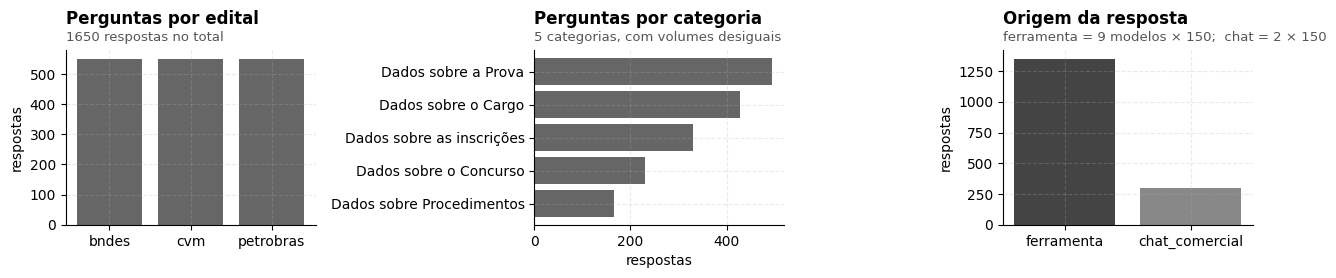

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

# Editais
e = df['edital'].value_counts()
axes[0].bar(e.index, e.values, color='#666')
titulo_acima(axes[0], 'Perguntas por edital', f'{len(df)} respostas no total')
axes[0].set_ylabel('respostas')

# Categorias
c = df['categoria'].value_counts()
axes[1].barh(c.index[::-1], c.values[::-1], color='#666')
titulo_acima(axes[1], 'Perguntas por categoria', '5 categorias, com volumes desiguais')
axes[1].set_xlabel('respostas')

# Origem
o = df['origem_resultado'].value_counts()
axes[2].bar(o.index, o.values, color=['#444', '#888'])
titulo_acima(axes[2], 'Origem da resposta', 'ferramenta = 9 modelos × 150;  chat = 2 × 150')
axes[2].set_ylabel('respostas')

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## 4. Precisão por modelo e por edital

Heatmap simples: linha é o modelo, coluna é o edital, célula é a precisão média (`avaliacao_final`).


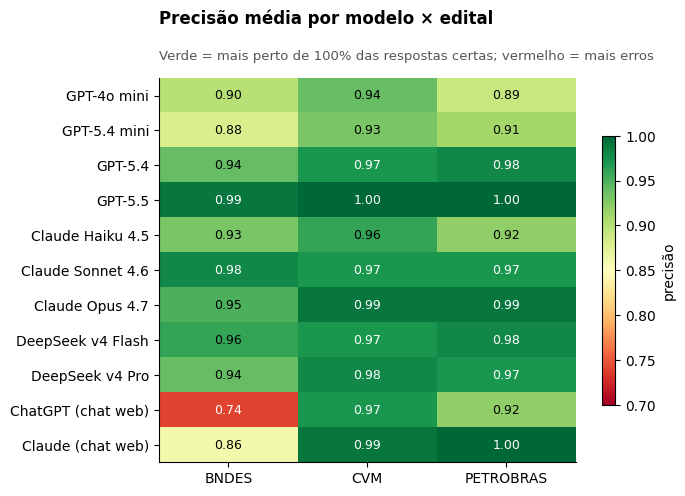

In [3]:
pivo = (df.groupby(['modelo_display','edital'])['avaliacao_final']
          .mean().unstack().loc[ORDEM_MODELOS])

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(pivo.values, cmap='RdYlGn', vmin=0.7, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(pivo.columns)))
ax.set_xticklabels([c.upper() for c in pivo.columns])
ax.set_yticks(range(len(pivo.index)))
ax.set_yticklabels(pivo.index)

# valores em cada célula
for i in range(pivo.shape[0]):
    for j in range(pivo.shape[1]):
        v = pivo.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9, color='black' if 0.85 < v < 0.97 else 'white')

titulo_acima(ax,
    'Precisão média por modelo × edital',
    'Verde = mais perto de 100% das respostas certas; vermelho = mais erros')
ax.set_xlabel('')
ax.set_ylabel('')
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.7, label='precisão')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

**O que dá pra ler no heatmap:**

- A grande maioria das células fica acima de 0,90 — todos os modelos respondem bem o domínio.
- O edital do **BNDES** é nitidamente o mais difícil para o chat web (`ChatGPT (chat web)` cai para 0,80). É o edital onde a ferramenta com RAG ganha mais espaço.
- **ChatGPT 5.5** é o único que praticamente fecha em 1,00 nos três editais.


## 5. Precisão por modelo × categoria de pergunta

Mesmo heatmap, agora cruzando com a categoria — para ver se algum modelo sofre numa área específica.


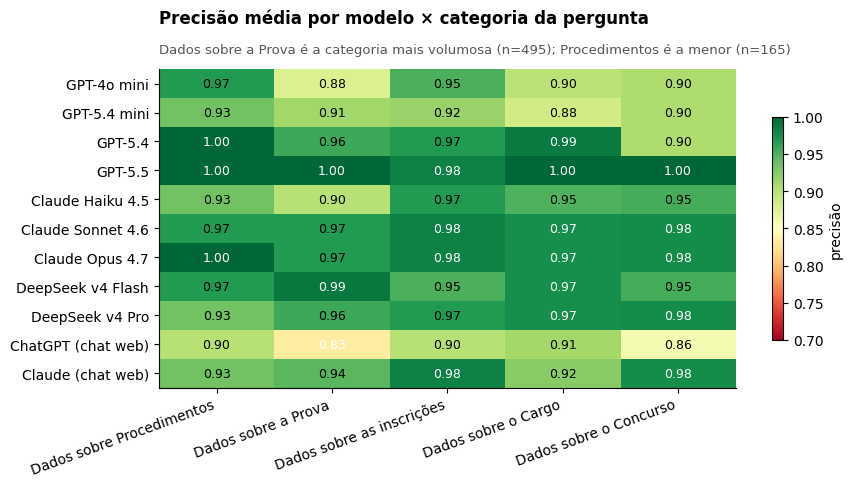

In [4]:
pivo_cat = (df.groupby(['modelo_display','categoria'])['avaliacao_final']
              .mean().unstack().loc[ORDEM_MODELOS])

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(pivo_cat.values, cmap='RdYlGn', vmin=0.7, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(pivo_cat.columns)))
ax.set_xticklabels(pivo_cat.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivo_cat.index)))
ax.set_yticklabels(pivo_cat.index)

for i in range(pivo_cat.shape[0]):
    for j in range(pivo_cat.shape[1]):
        v = pivo_cat.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=9, color='black' if 0.85 < v < 0.97 else 'white')

titulo_acima(ax,
    'Precisão média por modelo × categoria da pergunta',
    'Dados sobre a Prova é a categoria mais volumosa (n=495); Procedimentos é a menor (n=165)')
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.7, label='precisão')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## 6. O que vem a seguir

Com o panorama feito, os próximos notebooks abrem cada eixo:

| Notebook | Pergunta principal |
|---|---|
| `02_precisao.ipynb` | Quem acerta mais? Quanto os juízes concordam? Onde divergem? |
| `03_concisao.ipynb` | Quem responde direto ao ponto? Há trade-off com precisão? |
| `04_eficiencia_ferramenta.ipynb` | Quanto custa, quanto demora, e quanto disso é fluxo interno do modelo? |
| `05_sintese.ipynb` | A foto final consolidada e os scores combinados |
